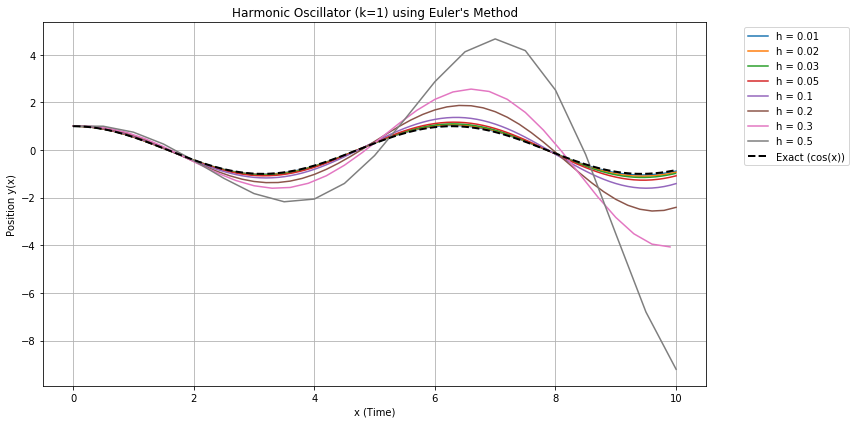

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Modifying the demo to loop through multiple h values
k = 1.0        # Spring constant
h_vals = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
x_start = 0    
x_end = 10     
y_0 = 1.0      
v_0 = 0.0      

plt.figure(figsize=(12, 6))

for h in h_vals:
    # Need to use np.arange carefully with floats, adding a tiny buffer ensures we hit x_end
    x_values = np.arange(x_start, x_end + (h/2), h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
    
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(x_values)):
        # Standard explicit Euler update
        y_values[i] = y_values[i - 1] + h * v_values[i - 1]
        v_values[i] = v_values[i - 1] - h * k * y_values[i - 1]
        
    # Plotting just the position y(x) to keep the graph readable
    plt.plot(x_values, y_values, label=f'h = {h}')

# Adding the exact analytical solution for comparison (which is cos(x) since k=1, y0=1, v0=0)
x_exact = np.linspace(x_start, x_end, 500)
plt.plot(x_exact, np.cos(x_exact), 'k--', linewidth=2, label='Exact (cos(x))')

plt.xlabel('x (Time)')
plt.ylabel('Position y(x)')
plt.title("Harmonic Oscillator (k=1) using Euler's Method")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.grid(True)
plt.tight_layout()
plt.show()

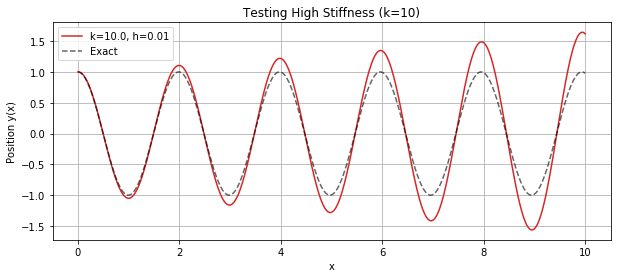

In [3]:
# 2. Testing the k = 10, h = 0.01 scenario
k_stiff = 10.0
h_stiff = 0.01

x_values_stiff = np.arange(x_start, x_end + (h_stiff/2), h_stiff)
y_values_stiff = np.zeros(len(x_values_stiff))
v_values_stiff = np.zeros(len(x_values_stiff))

y_values_stiff[0] = y_0
v_values_stiff[0] = v_0

for i in range(1, len(x_values_stiff)):
    y_values_stiff[i] = y_values_stiff[i - 1] + h_stiff * v_values_stiff[i - 1]
    v_values_stiff[i] = v_values_stiff[i - 1] - h_stiff * k_stiff * y_values_stiff[i - 1]

plt.figure(figsize=(10, 4))
plt.plot(x_values_stiff, y_values_stiff, color='tab:red', label=f'k={k_stiff}, h={h_stiff}')

# Exact solution for k=10 is cos(sqrt(10)*x)
plt.plot(x_exact, np.cos(np.sqrt(10)*x_exact), 'k--', alpha=0.6, label='Exact')

plt.xlabel('x')
plt.ylabel('Position y(x)')
plt.title("Testing High Stiffness (k=10)")
plt.legend()
plt.grid(True)
plt.show()

### Analysis and Observations

**When does it become unstable? Is it becoming unstable?**
Yes, it is highly unstable. Unlike the previous assignment where Euler caused artificial *damping* (losing energy), applying Explicit Euler to a harmonic oscillator ($d^2y/dx^2 = -ky$) does the exact opposite: it artificially *adds* energy to the system at every single step. 

Technically, Explicit Euler is unconditionally unstable for this specific equation for *any* step size $h$, meaning the amplitude will always grow over time. Visually, in our $x=10$ window, it becomes wildly unmanageable for larger step sizes. By $h = 0.3$ and $h = 0.5$, the position values explode exponentially, with the $h=0.5$ trajectory dropping completely off the expected path to nearly -9.

**Play with the value of K, what are you seeing?**
The variable $k$ acts as the "spring constant." Increasing $k$ does two things:
1. It increases the physical frequency of the oscillation.
2. It aggressively amplifies the numerical instability. 

Because the system is moving faster and the slope is changing more rapidly, the linear tangent approximation that Euler relies on becomes inaccurate much sooner in the curve. A higher $k$ causes the numerical energy injection to spiral out of control in fewer steps.

**Set $k = 10$, $h = 0.01$. Thoughts on whether Euler's Method can solve this with a larger $h$?**
Absolutely not. When we set $k=10$, we make the system "stiffer." Even at a tiny step size of $h=0.01$, looking at the second plot, the amplitude of the numerical solution is already visibly growing past the exact solution's bounds of $[-1, 1]$, reaching over $1.5$ by the end of the run. 

If we were to use a larger $h$ for this stiff system, the error multiplier would be massive, and the simulation would explode into numerical garbage almost instantly. To accurately solve a harmonic oscillator with Explicit Euler, as $k$ goes up, your $h$ must go drastically down just to keep the artificial energy growth barely noticeable.